# Random Forest — Classificação do Estado do Tabuleiro

Treina em `train.csv`, ajusta hiperparâmetros via `GridSearchCV` (cv=5 sobre o treino), valida em `val.csv` e reporta o desempenho final em `test.csv`.


## 1. Imports e Carregamento dos Splits


In [41]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

print("Carregando splits físicos...")
df_train = pd.read_csv('../../data/splits/train.csv')
df_val   = pd.read_csv('../../data/splits/val.csv')
df_test  = pd.read_csv('../../data/splits/test.csv')

# Separacao do Data frame: X(9 FEATURES ou POS) Y(Resultado dos jogos)
X_train, y_train_raw = df_train.drop('classe', axis=1), df_train['classe']
X_val,   y_val_raw   = df_val.drop('classe', axis=1),   df_val['classe']
X_test,  y_test_raw  = df_test.drop('classe', axis=1),  df_test['classe']

# Conversao de classe em inteiro
le = LabelEncoder().fit(y_train_raw) # .fit apenas no treino, para aprender apenas com as classes e dados dele
y_train = le.transform(y_train_raw)
y_val   = le.transform(y_val_raw)
y_test  = le.transform(y_test_raw)

print(f"Treino:    {len(X_train):4d} amostras")
print(f"Validação: {len(X_val):4d} amostras")
print(f"Teste:     {len(X_test):4d} amostras")
print(f"\nClasses: {list(le.classes_)}")

print("\nDistribuição das classes:")
print(y_train_raw.value_counts())
print(y_train_raw.value_counts(normalize=True).mul(100).round(1).astype(str) + '%')


Carregando splits físicos...
Treino:    1119 amostras
Validação:  241 amostras
Teste:      240 amostras

Classes: ['Empate', 'O venceu', 'Tem jogo', 'X venceu']

Distribuição das classes:
classe
Tem jogo    438
X venceu    438
O venceu    221
Empate       22
Name: count, dtype: int64
classe
Tem jogo    39.1%
X venceu    39.1%
O venceu    19.7%
Empate       2.0%
Name: proportion, dtype: object


## 2. Busca de Hiperparâmetros (GridSearchCV no Treino)


In [57]:
param_grid = {
    'n_estimators':      [100, 200, 300], # numero de arvores
    'max_depth':         [5, 10, 15, 20], # profundidade maxima na arvore
    'min_samples_split': [5, 10, 20], # minimo de amostras por no
    'min_samples_leaf':  [2, 4, 8], # minimo de amostras por folha
    'class_weight':      ['balanced', 'balanced_subsample'], # tratamento para classes desbalanciadas
    'max_features':      ['sqrt', 'log2', 0.5], # quantas feauture cada arvore considera em cada split
    'max_samples':       [0.7, 0.8, 0.9], # numero de amostras por arvore
}

search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=60, # sortei 60 combinacoes de jogo
    cv=5, # divide treino em 5 partes, treina 5 vezes, deixando uma parte de fora
    scoring='f1_weighted', # parametro que ajuda com as classes desbalnceadas
    n_jobs=-1, # paralelisnmo
    random_state=42,
    verbose=1,
)

print("Iniciando RandomizedSearchCV...")
search.fit(X_train, y_train)

print("\nMelhores parâmetros encontrados:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nMelhor F1 (CV): {search.best_score_:.4f}")


Iniciando RandomizedSearchCV...
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Melhores parâmetros encontrados:
  n_estimators: 300
  min_samples_split: 5
  min_samples_leaf: 2
  max_samples: 0.9
  max_features: 0.5
  max_depth: 10
  class_weight: balanced_subsample

Melhor F1 (CV): 0.8936


## 3. Treinamento do Modelo Final


In [58]:
rf_model = RandomForestClassifier(**search.best_params_, random_state=42) # Passa or melhores parametros, output anterior
rf_model.fit(X_train, y_train) # modelo final com 100% do X_train(treino)
print("Modelo final treinado.")


Modelo final treinado.


## 4. Avaliação no Conjunto de Validação


=== VALIDAÇÃO ===
              precision    recall  f1-score   support

      Empate       1.00      0.80      0.89         5
    O venceu       0.90      0.98      0.94        48
    Tem jogo       0.98      0.84      0.90        94
    X venceu       0.89      0.99      0.94        94

    accuracy                           0.93       241
   macro avg       0.94      0.90      0.92       241
weighted avg       0.93      0.93      0.92       241

Acurácia no Treino:    0.9946
Acurácia na Validação: 0.9253

⚠️  Diferença > 5pp entre treino e validação — possível overfitting.


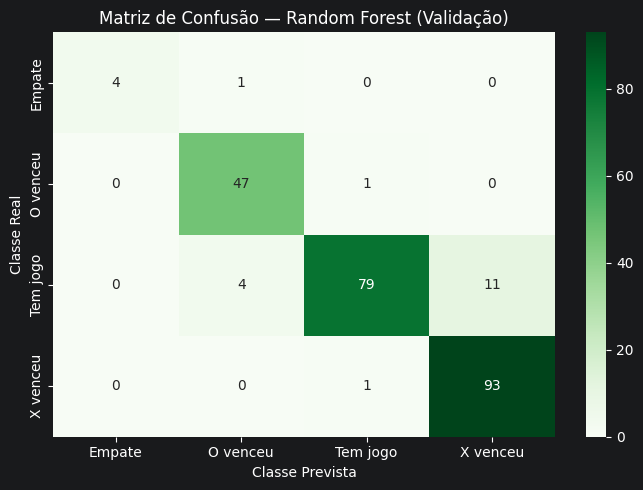

In [59]:
y_val_pred = rf_model.predict(X_val) # Previsao para cada amostra a partir do conjunto(features) de validacao

print("=== VALIDAÇÃO ===")
print(classification_report(
    le.inverse_transform(y_val), # conversao para texto
    le.inverse_transform(y_val_pred),  # conversao para texto
    zero_division=0,
))

acc_treino = rf_model.score(X_train, y_train)
acc_val    = rf_model.score(X_val,   y_val)
print(f"Acurácia no Treino:    {acc_treino:.4f}")
print(f"Acurácia na Validação: {acc_val:.4f}")
if acc_treino - acc_val > 0.05:
    print("\n⚠️  Diferença > 5pp entre treino e validação — possível overfitting.") # memorizou parte do teino
else:
    print("\n✅  Diferença treino/validação dentro do esperado.") #

plt.figure(figsize=(7, 5))
cm_val = confusion_matrix(le.inverse_transform(y_val), le.inverse_transform(y_val_pred), labels=le.classes_)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão — Random Forest (Validação)')
plt.ylabel('Classe Real'); plt.xlabel('Classe Prevista')
plt.tight_layout(); plt.show()


## 5. Avaliação Final no Conjunto de Teste


=== TESTE ===
              precision    recall  f1-score   support

      Empate       0.71      1.00      0.83         5
    O venceu       0.94      1.00      0.97        47
    Tem jogo       0.99      0.81      0.89        94
    X venceu       0.88      0.99      0.93        94

    accuracy                           0.92       240
   macro avg       0.88      0.95      0.91       240
weighted avg       0.93      0.92      0.92       240

Acurácia no Teste: 0.9208


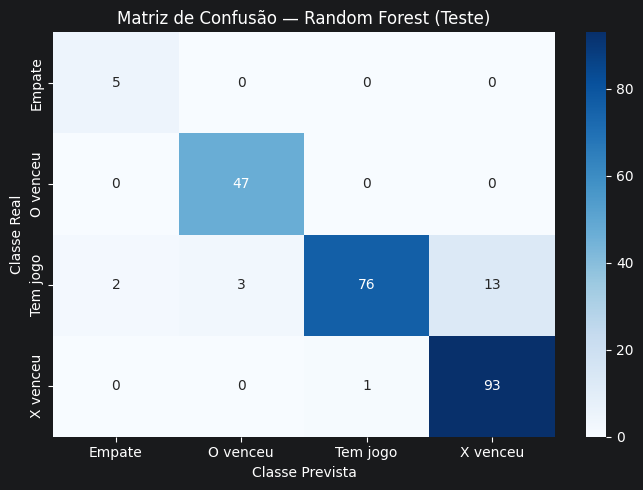

In [36]:
y_test_pred = rf_model.predict(X_test)

print("=== TESTE ===")
print(classification_report(
    le.inverse_transform(y_test),
    le.inverse_transform(y_test_pred),
    zero_division=0,
))

acc_teste = rf_model.score(X_test, y_test)
print(f"Acurácia no Teste: {acc_teste:.4f}")

plt.figure(figsize=(7, 5))
cm_test = confusion_matrix(le.inverse_transform(y_test), le.inverse_transform(y_test_pred), labels=le.classes_)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusão — Random Forest (Teste)')
plt.ylabel('Classe Real'); plt.xlabel('Classe Prevista')
plt.tight_layout(); plt.show()


## 6. Importância das Features


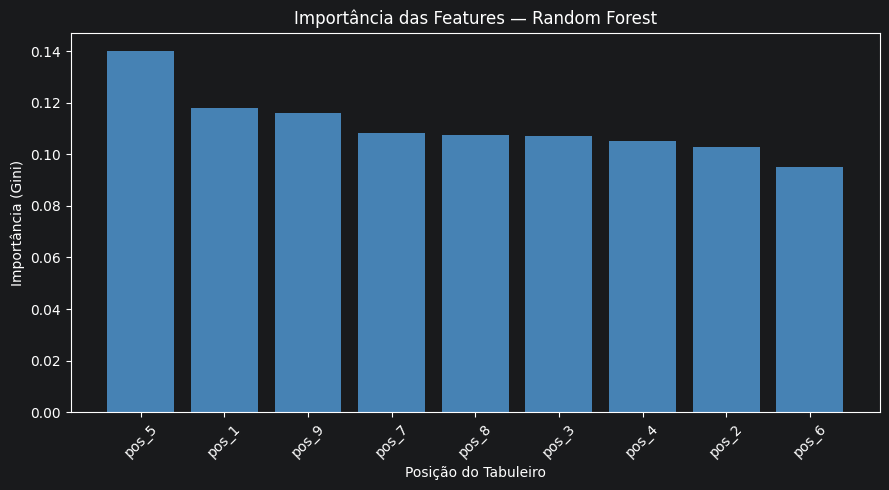


Importância por posição (ordenada):
  pos_5: 0.1401
  pos_1: 0.1181
  pos_9: 0.1158
  pos_7: 0.1083
  pos_8: 0.1074
  pos_3: 0.1071
  pos_4: 0.1052
  pos_2: 0.1029
  pos_6: 0.0951


In [16]:
importancias = rf_model.feature_importances_ # vetor de importancia calculado durante o treino
features = X_train.columns.tolist()
indices_ordenados = np.argsort(importancias)[::-1]

plt.figure(figsize=(9, 5))
plt.bar([features[i] for i in indices_ordenados],
        importancias[indices_ordenados], color='steelblue')
plt.title('Importância das Features — Random Forest')
plt.xlabel('Posição do Tabuleiro'); plt.ylabel('Importância (Gini)')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

print("\nImportância por posição (ordenada):")
for i in indices_ordenados:
    print(f"  {features[i]}: {importancias[i]:.4f}")


## 7. Persistência do Modelo


In [8]:
os.makedirs('../../models/RandomForest', exist_ok=True)
joblib.dump(rf_model, '../../models/RandomForest/rf_model.pkl')
joblib.dump(le,       '../../models/RandomForest/rf_label_encoder.pkl')
print("Modelo e Encoder salvos com sucesso!")


Modelo e Encoder salvos com sucesso!
